In [10]:
import pandas as pd
print("ok", pd.__version__)

ok 2.2.3


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Nat_Gas.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.tail())

(48, 2)
['Dates', 'Prices']
      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9
      Dates  Prices
43  5/31/24    11.4
44  6/30/24    11.5
45  7/31/24    11.6
46  8/31/24    11.5
47  9/30/24    11.8


C:\Users\Satvi\AppData\Local\Temp\ipykernel_8696\356307847.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[df.columns[0]])


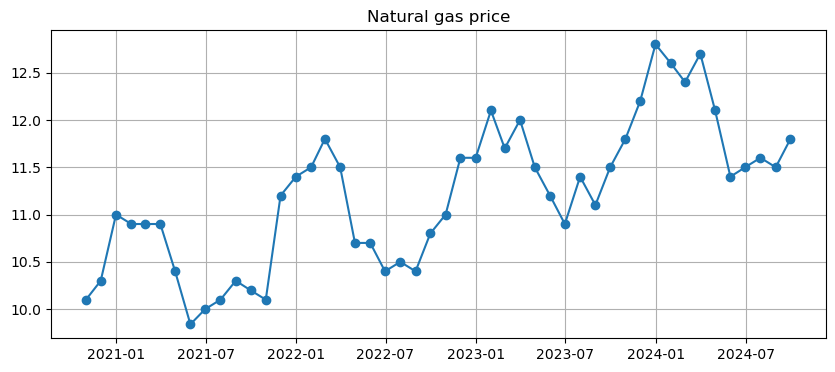

In [12]:
dates = pd.to_datetime(df[df.columns[0]])
prices = df[df.columns[1]]

plt.figure(figsize=(10, 4))
plt.plot(dates, prices, marker="o")
plt.title("Natural gas price")
plt.grid(True)
plt.show()


In [13]:
import numpy as np

df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates").reset_index(drop=True)

start = df["Dates"].min()
df["days"] = (df["Dates"] - start).dt.days

print(df.head())

       Dates  Prices  days
0 2020-10-31    10.1     0
1 2020-11-30    10.3    30
2 2020-12-31    11.0    61
3 2021-01-31    10.9    92
4 2021-02-28    10.9   120


C:\Users\Satvi\AppData\Local\Temp\ipykernel_8696\2821010126.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


slope: 0.0012823735987602238
intercept: 10.291041125952276


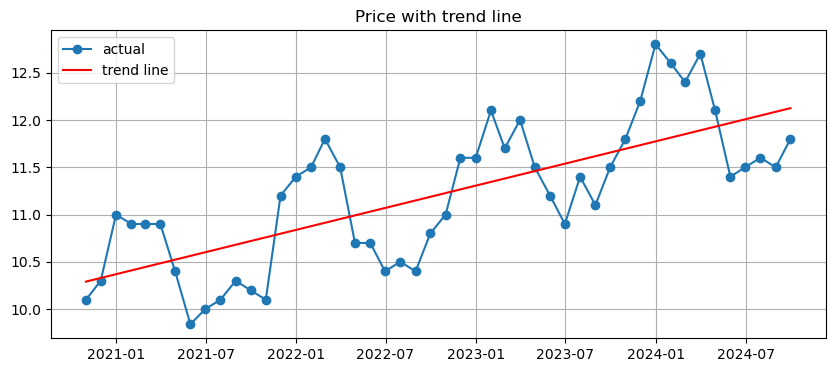

In [14]:
days = df["days"].values
prices = df["Prices"].values

slope, intercept = np.polyfit(days, prices, 1)
print("slope:", slope)
print("intercept:", intercept)

trend = slope * days + intercept

plt.figure(figsize=(10, 4))
plt.plot(df["Dates"], prices, marker="o", label="actual")
plt.plot(df["Dates"], trend, color="red", label="trend line")
plt.legend(); plt.grid(True); plt.title("Price with trend line")
plt.show()

A: 0.6642829791006534 B: -0.03302794208657074


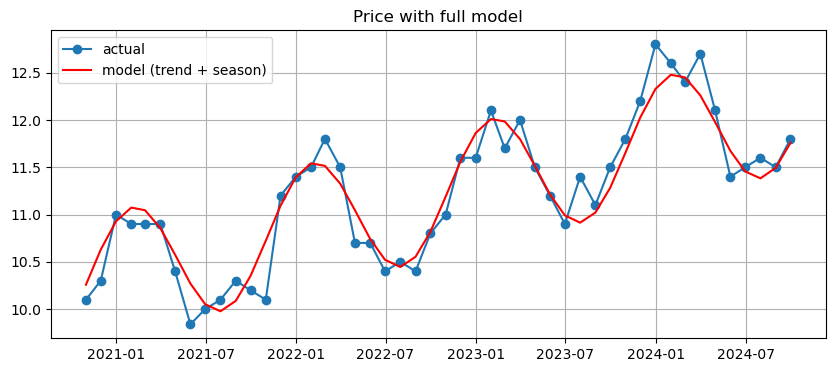

In [15]:
period = 365.25
theta = 2 * np.pi * df["days"].values / period

residual = prices - trend

features = np.column_stack([np.sin(theta), np.cos(theta)])
A, B = np.linalg.lstsq(features, residual, rcond=None)[0]
print("A:", A, "B:", B)

seasonal = A * np.sin(theta) + B * np.cos(theta)
model = trend + seasonal

plt.figure(figsize=(10, 4))
plt.plot(df["Dates"], prices, marker="o", label="actual")
plt.plot(df["Dates"], model, color="red", label="model (trend + season)")
plt.legend(); plt.grid(True); plt.title("Price with full model")
plt.show()

In [16]:
def estimate_price(date):
    date = pd.to_datetime(date)
    d = (date - start).days
    trend_part = slope * d + intercept
    theta = 2 * np.pi * d / period
    seasonal_part = A * np.sin(theta) + B * np.cos(theta)
    return trend_part + seasonal_part

print(estimate_price("2022-01-31"))   
print(estimate_price("2025-06-30"))   


11.541598594695987
11.925644900481098


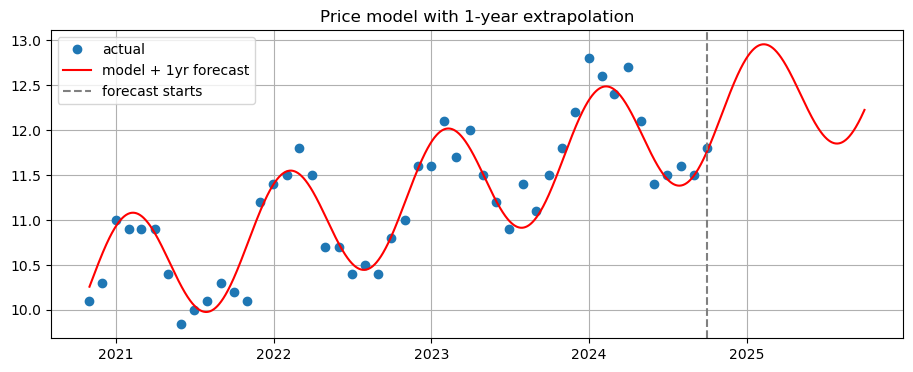

In [19]:
future_end = df["Dates"].max() + pd.Timedelta(days=365)
all_dates = pd.date_range(start=df["Dates"].min(), end=future_end, freq="D")
all_prices = [estimate_price(dt) for dt in all_dates]

plt.figure(figsize=(11, 4))
plt.plot(df["Dates"], prices, "o", label="actual")
plt.plot(all_dates, all_prices, color="red", label="model + 1yr forecast")
plt.axvline(df["Dates"].max(), color="gray", linestyle="--", label="forecast starts")
plt.legend(); plt.grid(True); plt.title("Price model with 1-year extrapolation")
plt.show()